# 1-LayoutLM

The LayoutLM model was proposed in the paper [LayoutLM: Pre-training of Text and Layout for Document Image Understanding](https://arxiv.org/abs/1912.13318).
 It’s a simple but effective pretraining method of text and layout for document image understanding and information extraction tasks, such as form understanding and receipt understanding. It obtains state-of-the-art results on several downstream tasks:
* form understanding: the FUNSD dataset (a collection of 199 annotated forms comprising more than 30,000 words).
* receipt understanding: the SROIE dataset (a collection of 626 receipts for training and 347 receipts for testing).
* document image classification: the RVL-CDIP dataset (a collection of 400,000 images belonging to one of 16 classes).

## Fine-tuning LayoutLM 
In this notebook, we are going to fine-tune the LayoutLM model on the SROIE dataset,which is a collection of annotated receipts.The goal of our model is to learn the the annotations of a number of labels("company","address","date","total","other") on those receipts,such that it can be used to annotate unseen receipts in the future.

# 2-Install libraries

In [1]:
import os
import glob
import json 
import random
from pathlib import Path
from difflib import SequenceMatcher
import shutil
from PIL import Image, ImageDraw, ImageFont
import cv2
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from IPython.display import display
import matplotlib
from matplotlib import pyplot, patches

# 3-Pre-processing the dataset
The first step, we have to preprocess the SROIE dataset which can be found from [here](https://www.kaggle.com/onchutrng/sroie20192021). The dataset contains multiple subfolders. For our purposes we only use two folders: 
- **task1_train** - contains receipt images (.jpg) and corresponding OCR'd bounding boxes and text (.txt)
- **task2_train** - contains labeled text (.txt) in a JSON format.

## Preparing the dataset

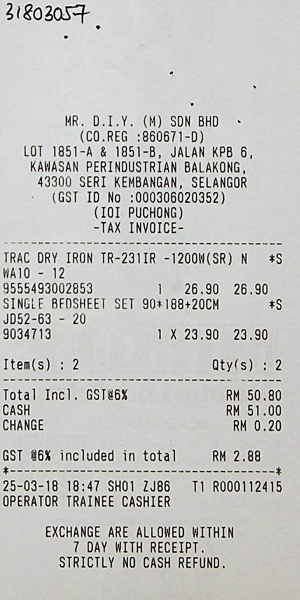

In [2]:
sroie_folder_path = Path('/kaggle/input/sroie20192021/SROIE2019/SROIE2019')
example_file = Path('X51005757324.txt')
image = Image.open("/kaggle/input/sroie20192021/SROIE2019/SROIE2019/task1_train/X51005757324.jpg")
image = image.convert("RGB")
new_image = image.resize((300, 600))
new_image

## Reading the words and bounding boxes
In the OCR data,each line in the file includes a group of words and a bounding box which defines them,we have to do is read the file and discard the unneeded points in the bounding box (because the model requires only the top-left and bottom-right points) and save it in Pandas Dataframe.

In [3]:
def read_bbox_and_words(path: Path):
  bbox_and_words_list = []

  with open(path, 'r') as f:
    for line in f.read().splitlines():
      split_lines = line.split(",")

      bbox = np.array(split_lines[0:8], dtype=np.int32)
      text = ",".join(split_lines[8:])

      # From the splited line we save (filename, [bounding box points], text line).
      # The filename will be useful in the future
      bbox_and_words_list.append([path.stem, *bbox, text])
    
  dataframe = pd.DataFrame(bbox_and_words_list, columns=['filename', 'x0', 'y0', 'x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'line'], dtype=np.int16)
  dataframe = dataframe.drop(columns=['x1', 'y1', 'x3', 'y3'])

  return dataframe


# Example usage
bbox_file_path = sroie_folder_path / "task1_train" / example_file
print("== File content ==")
!tail -n 10 "{bbox_file_path}"

bbox = read_bbox_and_words(path=bbox_file_path)
print("\n== Dataframe ==\n")
bbox.head(5)

== File content ==
6,928,104,928,104,955,6,955,CHANGE
550,929,665,929,665,958,550,958,RM 0.20
7,995,416,995,416,1025,7,1025,GST @6% INCLUDED IN TOTAL
502,997,616,997,616,1024,502,1024,RM 2.88
7,1063,402,1063,402,1092,7,1092,25-03-18 18:47 SHO1 ZJ86
453,1064,665,1064,665,1092,453,1092,T1 R000112415
6,1096,403,1096,403,1126,6,1126,OPERATOR TRAINEE CASHIER
107,1165,552,1165,552,1194,107,1194,EXCHANGE ARE ALLOWED WITHIN
171,1198,482,1198,482,1228,171,1228,7 DAY WITH RECEIPT.
139,1231,531,1231,531,1262,139,1262,STRICTLY NO CASH REFUND .

== Dataframe ==



,filename,x0,y0,x2,y2,line
0,X51005757324,153,253,516,286,MR. D.I.Y. (M) SDN BHD
1,X51005757324,190,287,482,318,(CO. REG :860671-D)
2,X51005757324,56,321,596,354,"LOT 1851-A & 1851-B, JALAN KPB 6 ,"
3,X51005757324,70,355,579,388,"KAWASAN PERINDUSTRIAN BALAKONG ,"
4,X51005757324,88,389,583,418,"43300 SERI KEMBANGAN, SELANGOR"


## Reading the entities file

In [4]:
def read_entities(path: Path):
  with open(path, 'r') as f:
    data = json.load(f)

  dataframe = pd.DataFrame([data])
  return dataframe


# Example usage
entities_file_path = sroie_folder_path / "task2_train" / example_file
print("== File content ==")
!head "{entities_file_path}"

entities = read_entities(path=entities_file_path)
print("\n\n== Dataframe ==")
entities

== File content ==
{
    "company": "MR. D.I.Y. (M) SDN BHD",
    "date": "25-03-18",
    "address": "LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERINDUSTRIAN BALAKONG, 43300 SERI KEMBANGAN, SELANGOR",
    "total": "50.80"
}

== Dataframe ==


,company,date,address,total
0,MR. D.I.Y. (M) SDN BHD,25-03-18,"LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...",50.80


## Assigning labels to words using the entities data
We have our words/lines and entities, now we just need to put them together by labeling our lines using the entities values. We'll be doing that by substring matching the entities values with the lines and if they don't match to a similarity check using pythons _difflib.SequenceMatcher_ and assigning anything above the 0.8 (80%) prediction match.

The **label "O"** will define all our words not labeled during the assignment step, because it's required for us to label everything.

In [5]:
# Assign a label to the line by checking the similarity
# of the line and all the entities
def assign_line_label(line: str, entities: pd.DataFrame):
    line_set = line.replace(",", "").strip().split()
    for i, column in enumerate(entities):
        entity_values = entities.iloc[0, i].replace(",", "").strip()
        entity_set = entity_values.split()

        matches_count = 0
        for l in line_set:
          if any(SequenceMatcher(a=l, b=b).ratio() > 0.8 for b in entity_set):
            matches_count += 1

        if matches_count == len(line_set) or matches_count == len(entity_set):
            return column.upper()

    return "O"


line = bbox.loc[3,"line"]
label = assign_line_label(line, entities)
print("Line:", line)
print("Assigned label:", label)

Line: KAWASAN PERINDUSTRIAN BALAKONG ,
Assigned label: ADDRESS


With a function which can handle the labeling of our lines, we'll create another function to label all our line in one DataFrame (so one receipt).

As simple as this could be, the problem arises when we get lines which would all pass the same match, like **TOTAL** for example; a receipt could have only one item on it and its price could be the same as the final total, so duplicate labels. Or maybe part of the address is also present at the end of the receipt.

To ignore such examples, I wrote simple hard-coded rules to assign *total* and *date* to only the largest bounding boxes it could find (based on its area) and to not allow the address to be assigned after date or total.

In [6]:
def assign_labels(words: pd.DataFrame, entities: pd.DataFrame):
    max_area = {"TOTAL": (0, -1), "DATE": (0, -1)}  # Value, index
    already_labeled = {"TOTAL": False,
                       "DATE": False,
                       "ADDRESS": False,
                       "COMPANY": False,
                       "O": False
    }

    # Go through every line in $words and assign it a label
    labels = []
    for i, line in enumerate(words['line']):
        label = assign_line_label(line, entities)

        already_labeled[label] = True
        if label == "ADDRESS" and (already_labeled["DATE"] or already_labeled["TOTAL"]):
            label = "O"

        # Assign to the largest bounding box
        if label in ["TOTAL", "DATE"]:
            x0_loc = words.columns.get_loc("x0")
            bbox = words.iloc[i, x0_loc:x0_loc+4].to_list()
            area = (bbox[2] - bbox[0]) + (bbox[3] - bbox[1])

            if max_area[label][0] < area:
                max_area[label] = (area, i)

            label = "O"

        labels.append(label)

    labels[max_area["DATE"][1]] = "DATE"
    labels[max_area["TOTAL"][1]] = "TOTAL"

    words["label"] = labels
    return words


# Example usage
bbox_labeled = assign_labels(bbox, entities)
bbox_labeled.head(10)

,filename,x0,y0,x2,y2,line,label
0,X51005757324,153,253,516,286,MR. D.I.Y. (M) SDN BHD,COMPANY
1,X51005757324,190,287,482,318,(CO. REG :860671-D),O
2,X51005757324,56,321,596,354,"LOT 1851-A & 1851-B, JALAN KPB 6 ,",ADDRESS
3,X51005757324,70,355,579,388,"KAWASAN PERINDUSTRIAN BALAKONG ,",ADDRESS
4,X51005757324,88,389,583,418,"43300 SERI KEMBANGAN, SELANGOR",ADDRESS
5,X51005757324,124,424,532,455,(GST ID NO :000306020352),O
6,X51005757324,222,455,432,486,(IOI PUCHONG),O
7,X51005757324,220,490,434,518,-TAX INVOICE-,O
8,X51005757324,8,557,583,588,TRAC DRY IRON TR-231IR - 1200W(SR) N,O
9,X51005757324,632,559,669,586,*S,O


In [7]:
Color_labeled = {"TOTAL": "Red","DATE": "Yellow","ADDRESS": "Green","COMPANY": "Blue","O": "Gray"}

def Draw_BBox(image_path,_bbox_labeled: pd.DataFrame):
    actual_boxes = []
    for idx, row in _bbox_labeled.iterrows():
        x0 = row['x0']
        y0 = row['y0']
        x2 = row['x2']
        y2 = row['y2']
        label= row['label']
        color=Color_labeled[label]
        actual_box = [x0, y0, x2, y2] # we turn it into (left, top, left+width, top+height) to get the actual box 
        draw = ImageDraw.Draw(image, "RGB")
        draw.rectangle(actual_box, outline=color,width=4)
        new_image = image.resize((300, 600))
    return new_image

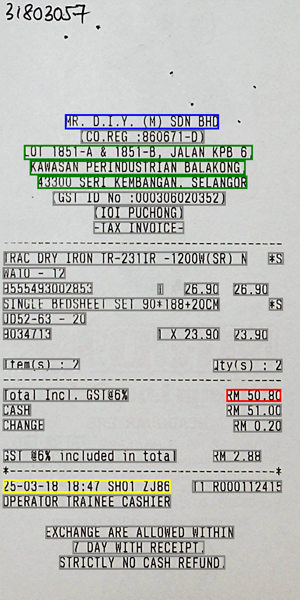

In [8]:
Draw_BBox(image,bbox_labeled)

## Split words
For the last part we're splitting the lines into separate tokens with their own bounding boxes.

Splitting the bounding boxes based on word length is probably not the best approach, but it's good enough.

In [9]:
def split_line(line: pd.Series):
  line_copy = line.copy()

  line_str = line_copy.loc["line"]
  words = line_str.split(" ")

  # Filter unwanted tokens
  words = [word for word in words if len(word) >= 1]

  x0, y0, x2, y2 = line_copy.loc[['x0', 'y0', 'x2', 'y2']]
  bbox_width = x2 - x0
  

  new_lines = []
  for index, word in enumerate(words):
    x2 = x0 + int(bbox_width * len(word)/len(line_str))
    line_copy.at['x0', 'x2', 'line'] = [x0, x2, word]
    new_lines.append(line_copy.to_list())
    x0 = x2 + 5 

  return new_lines


# Example usage
new_lines = split_line(bbox_labeled.loc[0])
print("Original row:")
display(bbox_labeled.loc[0:0,:])

print("Splitted row:")
pd.DataFrame(new_lines, columns=bbox_labeled.columns)

Original row:


,filename,x0,y0,x2,y2,line,label
0,X51005757324,153,253,516,286,MR. D.I.Y. (M) SDN BHD,COMPANY


Splitted row:


,filename,x0,y0,x2,y2,line,label
0,X51005757324,153,253,202,286,MR.,COMPANY
1,X51005757324,207,253,306,286,D.I.Y.,COMPANY
2,X51005757324,311,253,360,286,(M),COMPANY
3,X51005757324,365,253,414,286,SDN,COMPANY
4,X51005757324,419,253,468,286,BHD,COMPANY


## Putting it all together
We defined all our functions, now we just have to use them on every file and transform the dataset into a format which the script/model can parse.

In [10]:
from time import perf_counter
def dataset_creator(folder: Path, total=1000):
  bbox_folder = folder / 'task1_train'
  entities_folder = folder / 'task2_train'

  # Ignoring unwanted files which produced problems when I wanted to fine-tune the model with them included
  ignore = ['X51006619545.txt', 'X51006619785.txt', 'X51005663280(1).txt', 'X51005663280.txt'] 
  files = [file for file in bbox_folder.glob("*.txt") if file.name not in ignore]
  files = files[:total]

  data = []

  print("Reading dataset:")
  for file in tqdm(files, total=len(files)):
    bbox_file_path = file
    entities_file_path = entities_folder / file.name
    image_file_path = bbox_folder / file.with_suffix(".jpg")
  
    # Check if all the required files exist
    if not bbox_file_path.is_file() or not entities_file_path.is_file() or not image_file_path.is_file():
      continue
  
    # Read the files
    bbox = read_bbox_and_words(bbox_file_path)
    entities = read_entities(entities_file_path)
    image = Image.open(image_file_path)

    # Assign labels to lines in bbox using entities
    bbox_labeled = assign_labels(bbox, entities)
    del bbox

    # Split lines into separate tokens
    new_bbox_l = []
    for index, row in bbox_labeled.iterrows():
      new_bbox_l += split_line(row)
    new_bbox = pd.DataFrame(new_bbox_l, columns=bbox_labeled.columns, dtype=np.int16)
    del bbox_labeled


    # Do another label assignment to keep the labeling more precise 
    for index, row in new_bbox.iterrows():
      label = row['label']

      if label != "O":
        entity = entities.iloc[0, entities.columns.get_loc(label.lower())]
        if row['line'] not in entity:
          label = "O"
        else:
            # Not really IOB tagging, but it gives the best results
            label = "S-" + label
      
      new_bbox.at[index, 'label'] = label

    width, height = image.size
  
    data.append([new_bbox, width, height])

  return data


dataset = dataset_creator(sroie_folder_path)

Reading dataset:


  0%|          | 0/832 [00:00<?, ?it/s]

## Writing the dataset into training and testing files
With our dataset transformed, we'll split the dataset into a training and test set.

In [11]:
random.Random(4).shuffle(dataset)

# Set split point to be 80% of the dataset
split_point = int(len(dataset) * 0.8) 

dataset_train  = dataset[:split_point]
dataset_test = dataset[split_point:]
del(dataset)

## Defining the writing function
We'll use the same function to write into the train and test files

The normalization function is meant to normalize the bounding boxes points in a range [0,1000] using the width and height of the image.

In [12]:
def normalize(points: list, width: int, height: int) -> list:
  x0, y0, x2, y2 = [int(p) for p in points]
  
  x0 = int(1000 * (x0 / width))
  x2 = int(1000 * (x2 / width))
  y0 = int(1000 * (y0 / height))
  y2 = int(1000 * (y2 / height))

  return [x0, y0, x2, y2]


def write_dataset(dataset: list, output_dir: Path, name: str):
  print(f"Writing {name}ing dataset:")
  with open(output_dir / f"{name}.txt", "w+", encoding="utf8") as file, \
       open(output_dir / f"{name}_box.txt", "w+", encoding="utf8") as file_bbox, \
       open(output_dir / f"{name}_image.txt", "w+", encoding="utf8") as file_image:

      # Go through each dataset
      for datas in tqdm(dataset, total=len(dataset)):
        data, width, height = datas
        
        filename = data.iloc[0, data.columns.get_loc('filename')]

        # Go through every row in dataset
        for index, row in data.iterrows():
          bbox = [int(p) for p in row[['x0', 'y0', 'x2', 'y2']]]
          normalized_bbox = normalize(bbox, width, height)

          file.write("{}\t{}\n".format(row['line'], row['label']))
          file_bbox.write("{}\t{} {} {} {}\n".format(row['line'], *normalized_bbox))
          file_image.write("{}\t{} {} {} {}\t{} {}\t{}\n".format(row['line'], *bbox, width, height, filename))

        # Write a second newline to separate dataset from others
        file.write("\n")
        file_bbox.write("\n")
        file_image.write("\n")

In [13]:
dataset_directory = Path('/kaggle/working','dataset')

dataset_directory.mkdir(parents=True, exist_ok=True)

write_dataset(dataset_train, dataset_directory, 'train')
write_dataset(dataset_test, dataset_directory, 'test')

# Creating the 'labels.txt' file to the the model what categories to predict.
labels = ['COMPANY', 'DATE', 'ADDRESS', 'TOTAL']
IOB_tags = ['S']
with open(dataset_directory / 'labels.txt', 'w') as f:
  for tag in IOB_tags:
    for label in labels:
      f.write(f"{tag}-{label}\n")
  f.write("O")

Writing training dataset:


  0%|          | 0/531 [00:00<?, ?it/s]

Writing testing dataset:


  0%|          | 0/133 [00:00<?, ?it/s]

# 4-Fine tune LayoutLM
We downloaded and transformed our dataset into a trainable and testable set, now we can start the fine-tuning of the model.

## Download the model
First we're going to clone the LayoutLM Github project which contains the script to fine tune our model.

In [14]:
%%bash
cd /kaggle/working
git clone https://github.com/microsoft/unilm.git
cd unilm/layoutlm/deprecated
pip install .

Processing /kaggle/working/unilm/layoutlm/deprecated
  Created wheel for layoutlm: filename=layoutlm-0.0-py3-none-any.whl size=11484 sha256=875da901a17aa5c652f5aed7bbfe0ab3fa2d4a8f079b829fd79081d6c43785a7
  Stored in directory: /tmp/pip-ephem-wheel-cache-lo75i59l/wheels/47/19/c8/4d4f4e6e079254246e6f4a458c20617a8380e2364824c13474
  Created wheel for seqeval: filename=seqeval-0.0.12-py3-none-any.whl size=7422 sha256=fe4af0778104c9238521374a15700a51c77baee39ffb0607c7481dde957b125f
  Stored in directory: /root/.cache/pip/wheels/dc/cc/62/a3b81f92d35a80e39eb9b2a9d8b31abac54c02b21b2d466edc
Successfully built layoutlm seqeval
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.9.4
    Uninstalling tokenizers-0.9.4:
      Successfully uninstalled tokenizers-0.9.4
  Attempting uninstall: transformers
    Found existing installation: transformers 4.0.1
    Uninstalling transformers-4.0.1:
      Successfully uninstalled transformers-4.0.1
  Attempting uninstall: tensor

Cloning into 'unilm'...
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gym 0.18.0 requires Pillow<=7.2.0, but you have pillow 9.3.0 which is incompatible.
catalyst 20.12 requires tensorboardX>=2.1.0, but you have tensorboardx 2.0 which is incompatible.
bokeh 2.2.3 requires tornado>=5.1, but you have tornado 5.0.2 which is incompatible.
allennlp 1.3.0 requires transformers<4.1,>=4.0, but you have transformers 2.9.0 which is incompatible.
You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


## Training

In [15]:
pretrained_model_folder_input=Path('/kaggle/input/d/patriciamedyna/layoutlm/unilm/layoutlm/layoutlm-base-uncased/') # Define it so we can copy it into our working directory
label_file=Path(dataset_directory, "labels.txt")
dataset_dir="/kaggle/working/dataset"

# Move to the  directory
os.chdir("/kaggle/working/unilm/layoutlm/deprecated/examples/seq_labeling")

In [16]:
! cat "/kaggle/input/d/patriciamedyna/layoutlm/unilm/layoutlm/layoutlm-base-uncased/config.json"

{
  "attention_probs_dropout_prob": 0.1,
  "finetuning_task": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "max_2d_position_embeddings": 1024,
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "num_labels": 2,
  "output_attentions": false,
  "output_hidden_states": false,
  "output_past": true,
  "pruned_heads": {},
  "torchscript": false,
  "type_vocab_size": 2,
  "use_bfloat16": false,
  "vocab_size": 30522
}

In [17]:
print(os.getcwd())

/kaggle/working/unilm/layoutlm/deprecated/examples/seq_labeling


In [18]:
! python run_seq_labeling.py \
                            --data_dir "{dataset_dir}" \
                            --labels "{label_file}" \
                            --model_name_or_path "{pretrained_model_folder_input}" \
                            --model_type layoutlm \
                            --max_seq_length 512 \
                            --do_lower_case \
                            --do_train \
                            --num_train_epochs 1 \
                            --logging_steps 50 \
                            --save_steps -1 \
                            --output_dir output \
                            --overwrite_output_dir \
                            --per_gpu_train_batch_size 8 \
                            --per_gpu_eval_batch_size 16

Iteration:   0%|                                         | 0/67 [00:00<?, ?it/s]/opt/conda/lib/python3.7/site-packages/transformers/optimization.py:155: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha) (Triggered internally at  /opt/conda/conda-bld/pytorch_1603729138878/work/torch/csrc/utils/python_arg_parser.cpp:882.)
  exp_avg.mul_(beta1).add_(1.0 - beta1, grad)

Iteration:  73%|███████████████████████▍        | 49/67 [00:23<00:08,  2.14it/s]/opt/conda/lib/python3.7/site-packages/torch/optim/lr_scheduler.py:247: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  warnings.warn("To get the last learning rate computed by the scheduler, "

Epoch: 100%|██████████████████████████████████████| 1/1 [00:31<00:00, 31.66s/it]


# 5-Predicting

In [19]:
# Evaluate for test set and make predictions
! python run_seq_labeling.py \
                            --data_dir /kaggle/working/dataset \
                            --labels /kaggle/working/dataset/labels.txt \
                            --model_name_or_path "{pretrained_model_folder_input}" \
                            --model_type layoutlm \
                            --do_lower_case \
                            --max_seq_length 512 \
                            --do_predict \
                            --logging_steps 10 \
                            --save_steps -1 \
                            --output_dir output \
                            --per_gpu_eval_batch_size 8

Evaluating: 100%|███████████████████████████████| 17/17 [00:02<00:00,  6.43it/s]


In [20]:
cat output/test_results.txt

f1 = 0.9225496915695681
loss = 0.07585778394166161
precision = 0.9041648007165248
recall = 0.9416977611940298


## Example of a prediction
The example shows two side by side images of the same receipt, where the colored boxes are the labeled lines. The left is the *original*, so the data we labeled and the right is the model's prediction.

In [21]:
import cv2
from matplotlib import pyplot, patches
import matplotlib

data = pd.read_csv("/kaggle/working/dataset/test_image.txt", delimiter="\t", names=["name", "bbox", "size", "image"])
data_category = pd.read_csv("/kaggle/working/dataset/test.txt", delimiter="\t", names=["name", "true_category"]).drop(columns=["name"])
data_prediction_category = pd.read_csv("output/test_predictions.txt", delimiter=" ", names=["name", "prediction_category"]).drop(columns=["name"])

data_merge = data.merge(data_category, left_index=True, right_index=True)
merged = data_merge.merge(data_prediction_category, left_index=True, right_index=True)
merged_groups = list(merged.groupby("image"))

In [22]:
def display_prediction(data):
  colors = {
      "S-TOTAL": (255,0,0),
      "S-DATE": (0,255,0),
      "S-ADDRESS": (0,0, 255),
      "S-COMPANY": (255,255,0),
      "O": (192,192,192)
  }

  imagename = data[0].split(".")[0] + ".jpg"
  print("Filename:",imagename)
  image_path = str(sroie_folder_path / "task1_train" / imagename)

  img=cv2.imread(image_path)
  img_prediction=cv2.imread(image_path)

  data = data[1]
  for bbox, category, prediction_category in zip(data['bbox'], data['true_category'], data['prediction_category']):
    (x1, y1, x2, y2) = [int(coordinate) for coordinate in bbox.split()]

    img_prediction = cv2.rectangle(img_prediction, (x1, y1), (x2, y2), colors[prediction_category], 2 if "O" in prediction_category else 4)
    img = cv2.rectangle(img, (x1, y1), (x2, y2), colors[category], 2 if "O" in category else 4)

  matplotlib.rcParams['figure.figsize'] = 15 ,18

  cv2.imwrite("prediction.jpg", img_prediction)

  # Plot
  fig, ax = matplotlib.pyplot.subplots(1,2)
  ax[0].set_title("Original", fontsize= 30)
  ax[0].imshow(img);
  ax[1].set_title("Prediction", fontsize= 30)
  ax[1].imshow(img_prediction);

  # Legend
  handles = [
      patches.Patch(color='yellow', label='Company'),
      patches.Patch(color='blue', label='Address'),
      patches.Patch(color='green', label='Date'),
      patches.Patch(color='red', label='Total'),
      patches.Patch(color='gray', label='Other')
  ]

  fig.legend(handles=handles, prop={'size': 25}, loc='lower center')

Filename: X51005568899.jpg


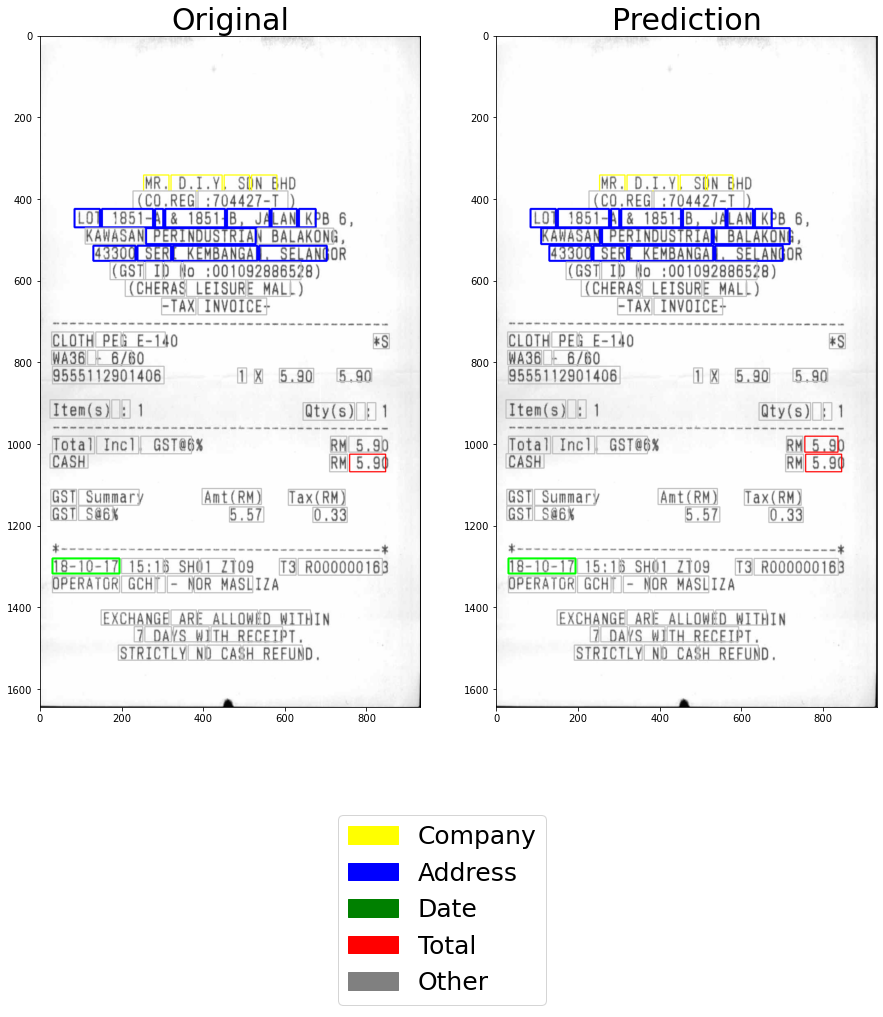

In [23]:
display_prediction(merged_groups[12])

This is an example when my preprocessing wasn't perfect, but the model still predicted the correct result. From this we can see that if my preprocessing was better, the model would have a better accuracy score.

Filename: X51005568911.jpg


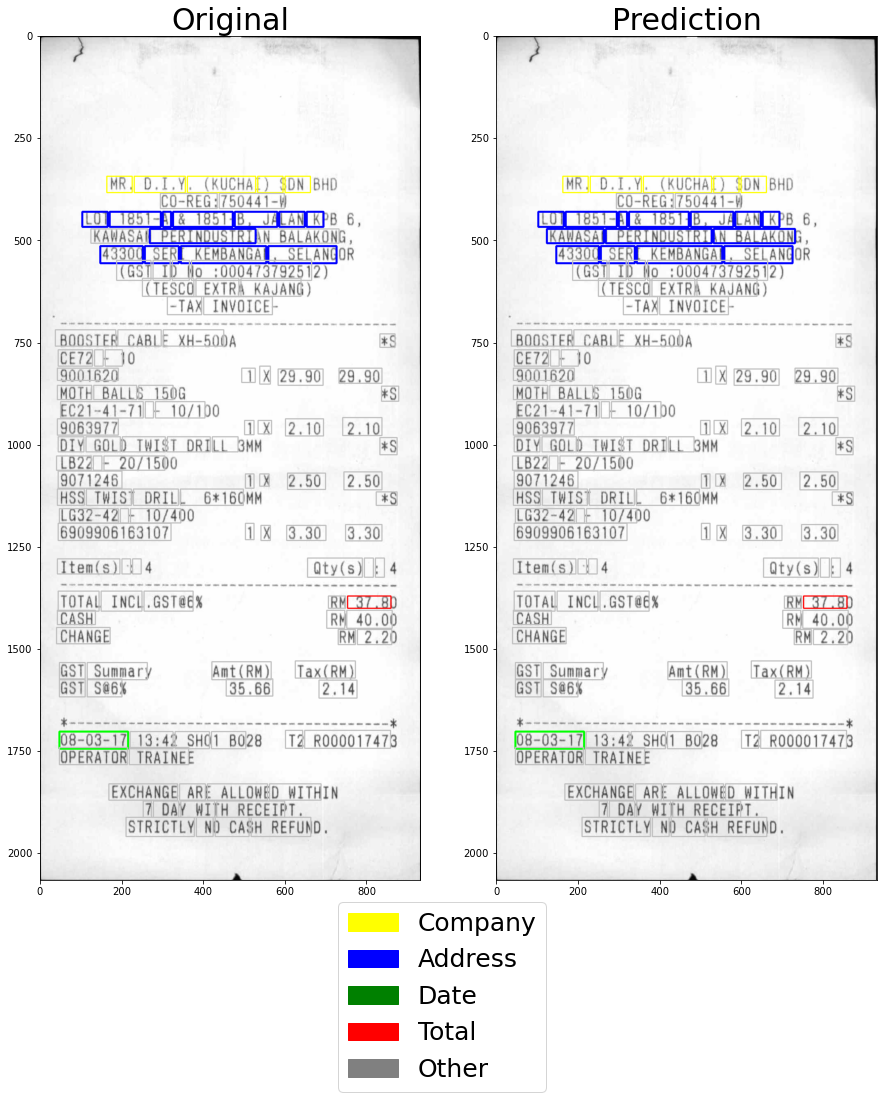

In [24]:
display_prediction(merged_groups[13])

In [25]:
!zip -r /kaggle/working/layoutlm_finetuned.zip \
     /kaggle/working/unilm/layoutlm/deprecated/examples/seq_labeling/output

  adding: kaggle/working/unilm/layoutlm/deprecated/examples/seq_labeling/output/ (stored 0%)
  adding: kaggle/working/unilm/layoutlm/deprecated/examples/seq_labeling/output/test_predictions.txt (deflated 77%)
  adding: kaggle/working/unilm/layoutlm/deprecated/examples/seq_labeling/output/tokenizer_config.json (deflated 34%)
  adding: kaggle/working/unilm/layoutlm/deprecated/examples/seq_labeling/output/vocab.txt (deflated 53%)
  adding: kaggle/working/unilm/layoutlm/deprecated/examples/seq_labeling/output/special_tokens_map.json (deflated 40%)
  adding: kaggle/working/unilm/layoutlm/deprecated/examples/seq_labeling/output/training_args.bin (deflated 45%)
  adding: kaggle/working/unilm/layoutlm/deprecated/examples/seq_labeling/output/test_results.txt (deflated 23%)
  adding: kaggle/working/unilm/layoutlm/deprecated/examples/seq_labeling/output/config.json (deflated 54%)
  adding: kaggle/working/unilm/layoutlm/deprecated/examples/seq_labeling/output/pytorch_model.bin (deflated 8%)


In [26]:
import shutil

shutil.make_archive('lm2', 'zip', '/kaggle/working/unilm/layoutlm/deprecated/examples/seq_labeling/output')

'/kaggle/working/unilm/layoutlm/deprecated/examples/seq_labeling/lm2.zip'

In [27]:
from IPython.display import FileLink
FileLink(r'/kaggle/working/unilm/layoutlm/deprecated/examples/seq_labeling/lm2.zip')

/kaggle/working/unilm/layoutlm/deprecated/examples/seq_labeling/lm2.zip

# 6-References

1. https://huggingface.co/transformers/model_doc/layoutlm.html
1. https://www.kaggle.com/urbikn/layoutlm-using-the-sroie-dataset